#Modelos generativos para detección de comunidades (SBM)

En este notebook vamos a trabajar con el Stochastic Block Model, veremos cómo implementarlo y cómo comparar sus resultados contra el tradicional método de maximización de modularidad y con variantes propias del modelo.

Para esto vamos a trabajar más que nada con [graph-tool](https://graph-tool.skewed.de/), una librería de python que está orientada a la manipulación y análisis estadístico de grafos. A diferencia de otras, corre sus procesos en C++, generando así una performance más eficiente en términos de consumo de recursos en las compus. Al margen de la dificultad de entrarle a la documentación, resulta muy adecuada para redes grandes, visualizaciones y cálculo de medidas de centralidad. También tiene bastantes funcionalidades vinculadas con inferencia de comunidades, reconstrucción y dinámica en redes.

In [ ]:
 # Esta celda de instalación del paquete está sugerida por los mismos creadores de graph-tool
!pip install -q condacolab
import condacolab
# Workaround issue with Python 3.12:
# condacolab.install()
condacolab.install_from_url("https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh")
!mamba install -q graph-tool
# Workaround issue with Python 3.12
!mamba install -q scipy

✨🍰✨ Everything looks OK!


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from community import community_louvain  # Louvain

import graph_tool.all as gt

def nx_to_gt(G): # Función para mapear objetos de networkx a graph-tool
    g = gt.Graph(directed=False)
    mapping = {}

    for i, node in enumerate(G.nodes()):
        mapping[node] = g.add_vertex()

    for u, v in G.edges():
        g.add_edge(mapping[u], mapping[v])

    return g

# Comparación Louvain vs SBM en grafo ER
Trabajamos la comparación entre los dos métodos para un grafo que en principio no debería tener estructura de comunidades. Para esto, usamos un grafo tipo erdos-renyi. Networkx ofrece una función para generarlos de forma directa (¿podrían implementarlo ustedes?)


In [ ]:
np.random.seed(42)

n = 1000
p = 0.01 # Con estos parámetros, ¿en qué regimen estamos?

G_nx = nx.erdos_renyi_graph(n, p, seed=42)

print(f"Nodos: {G_nx.number_of_nodes()}")
print(f"Aristas: {G_nx.number_of_edges()}")
print(f'Grado medio: {np.mean([v for k, v in G_nx.degree()])}')

Nodos: 1000
Aristas: 4985
Grado medio: 9.97


## Louvain
Aplicamos el algoritmo de louvain sobre el grafo ER. Es bastante directo y nos devuelve un diccionario nodo-comunidad.

In [ ]:
partition = community_louvain.best_partition(G_nx)
modularity_louvain = community_louvain.modularity(partition, G_nx)

n_communities_louvain = len(set(partition.values()))

print("Louvain:")
print("Número de comunidades:", n_communities_louvain)
print("Modularidad:", modularity_louvain)

Louvain:
Número de comunidades: 15
Modularidad: 0.2782221488940241


## SBM
Primero, llevamos el grafo de nx a un objeto de graph-tool, luego usamos el sbm. Graph-tool no nos devuelve un diccionario si no que nos devuelve un "estado" producto de ajustar el modelo SBM al grafo, que contiene varios métodos, entre ellos: los bloques. El objeto bloques es lo que en graph-tool se lleva como vertex-property.

In [ ]:
G_gt = nx_to_gt(G_nx)

state = gt.minimize_blockmodel_dl(G_gt) # Por default, trabaja con la versión degree-corrected
blocks = state.get_blocks() # Obtenemos el vertex-property asociado a los bloques que encontró el algoritmo

b = [blocks[v] for v in G_gt.vertices()]
n_blocks = len(set(b))

print("\nSBM:")
print("Número de bloques:", n_blocks)

partition_sbm = {i: b[i] for i in range(len(b)) }# Convertir partición SBM a formato networkx

modularity_sbm = community_louvain.modularity(partition_sbm, G_nx)

print("Modularidad (SBM):", modularity_sbm)


SBM:
Número de bloques: 1
Modularidad (SBM): 0.0


## Comparación gráfica
Vemos qué comunidades está detectando louvain vs la que genera graph-tool. Para esto, vamos a usar graph-tool que, si bien necesita que le pasemos vertex-properties o edge-properties para mejorar la visualización, resulta muy rápida para generar visualizaciones, incluso con redes grandes.

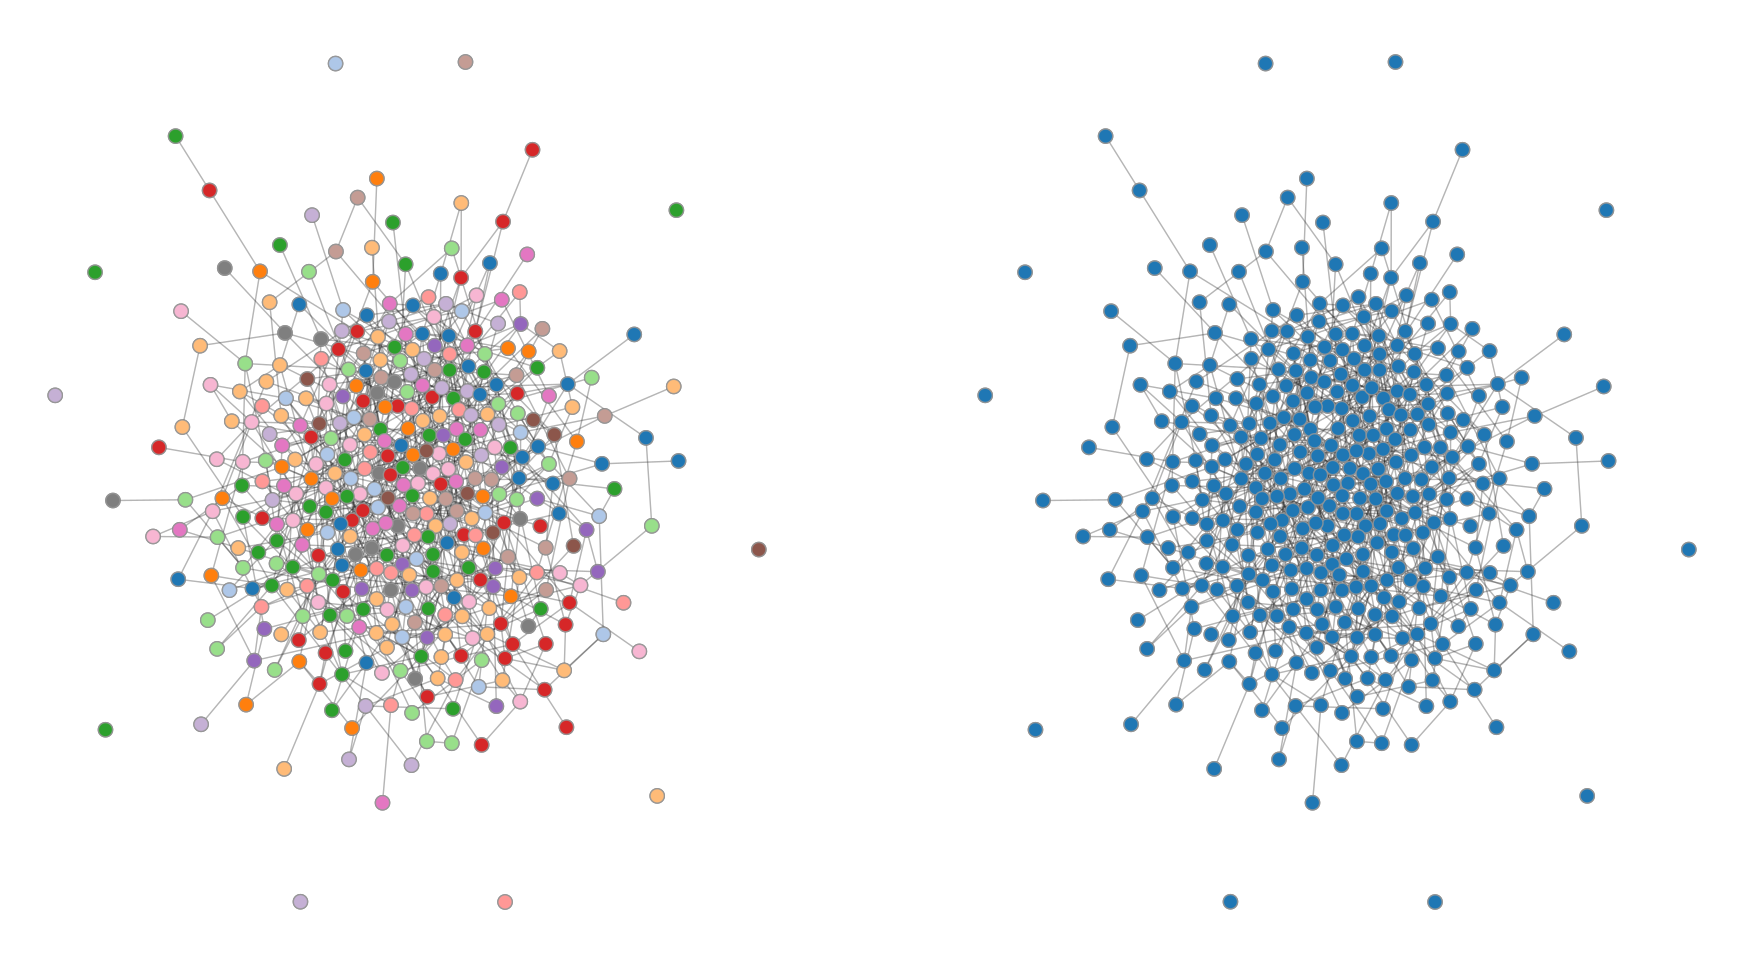

In [ ]:
color_louvain = G_gt.new_vertex_property("int")

for i, v in enumerate(G_gt.vertices()):
    color_louvain[v] = partition[i]

color_sbm = G_gt.new_vertex_property("int")

for i, v in enumerate(G_gt.vertices()):
    color_sbm[v] = partition_sbm[i]

sample_nodes = np.random.choice(list(G_gt.get_vertices()), size = 500)
u = gt.GraphView(G_gt, vfilt = lambda v: v in sample_nodes) # Sampleamos un conjunto de nodos para facilitar la visualización

pos = gt.sfdp_layout(u) # generamos un único posicionamiento de los nodos para ambos grafos

# Louvain
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (11, 6), dpi = 200)
gt.graph_draw(
    u,
    pos=pos,
    vertex_fill_color=color_louvain,
    vertex_size=3,
    edge_color = (0.1,0.1,0.1,0.3),
    mplfig=ax1
)

# SBM
gt.graph_draw(
    u,
    pos=pos,
    vertex_fill_color=color_sbm,
    vertex_size=3,
    edge_color = (0.1,0.1,0.1,0.3),
    mplfig=ax2
)

for ax in fig.get_axes():
    ax.axis('off')

## ¿Qué pasa a nivel ensamble?
Si bien vimos cómo es la performance de ambos métodos en una realización, deberíamos hacer esto repetidas veces. Para esto, vamos a generar N grafos aleatorias de ER y sobre cada uno corremos louvain y sbm y contabilizamos la cantidad de comunidades detectadas y la modularidad asociada a las mismas. De esta forma, podremos comparar a nivel distribuciones lo que pasa con ambos métodos.

In [ ]:
np.random.seed(42)


# parámetros
n = 300
p = 0.02
n_runs = 200

# Para louvain
louvain_comms = [] # Lista de cantidad de comunidades
louvain_mods = [] # Lista de modularidad

# Para SBM
sbm_comms = [] # Lista de cantidad de comunidades
sbm_mods = [] # Lista de modularidad

for i in range(n_runs):
    # --- generar ER ---
    G_nx = nx.erdos_renyi_graph(n, p)

    # --- Louvain ---
    partition = community_louvain.best_partition(G_nx)
    mod_louvain = community_louvain.modularity(partition, G_nx)

    louvain_comms.append(len(set(partition.values())))
    louvain_mods.append(mod_louvain)

    # --- SBM ---
    G_gt = nx_to_gt(G_nx)
    state = gt.minimize_blockmodel_dl(G_gt)
    blocks = state.get_blocks()

    b = [blocks[v] for v in G_gt.vertices()]
    sbm_comms.append(len(set(b)))

    # modularidad de SBM (evaluada con Louvain)
    partition_sbm = {i: b[i] for i in range(len(b))}
    mod_sbm = community_louvain.modularity(partition_sbm, G_nx)
    sbm_mods.append(mod_sbm)



Analicemos los resultados con histogramas. De forma brusca, nos vamos a encontrar con lo que pasó con el SBM.

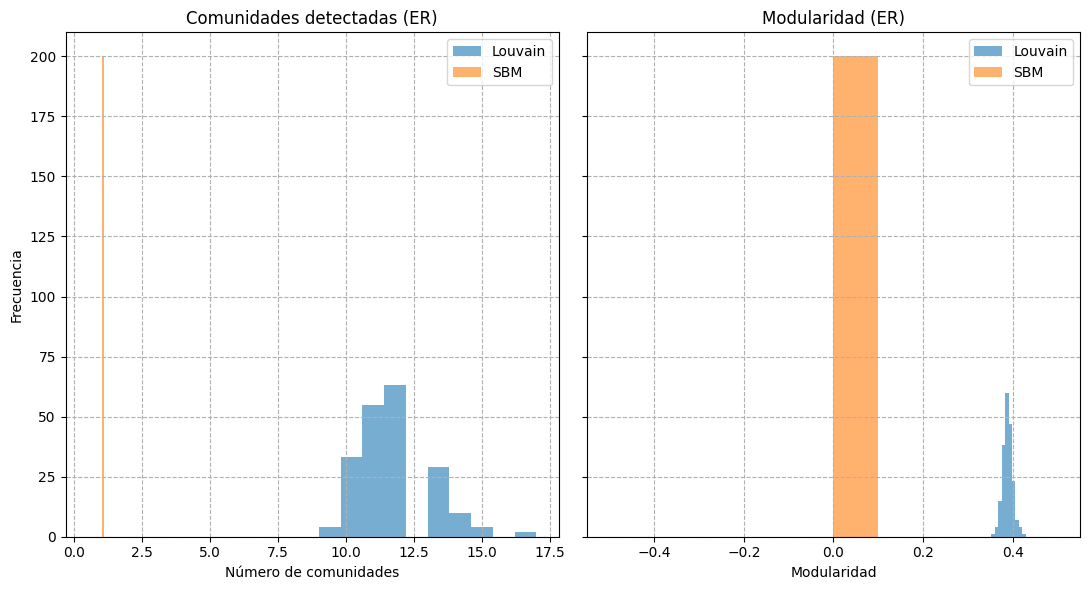

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey = True)

# --- Número de comunidades ---
axes[0].hist(louvain_comms, alpha=0.6, label="Louvain")
axes[0].hist(sbm_comms, alpha=0.6, label="SBM")
axes[0].set_xlabel("Número de comunidades")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Comunidades detectadas (ER)")
axes[0].legend()

# --- Modularidad ---
axes[1].hist(louvain_mods, alpha=0.6, label="Louvain")
axes[1].hist(sbm_mods, alpha=0.6, label="SBM")
axes[1].set_xlabel("Modularidad")
axes[1].set_title("Modularidad (ER)")
axes[1].legend()

for ax in fig.get_axes():
    ax.grid(linestyle = 'dashed')


plt.tight_layout()
plt.show()

# Comparación Degree corrected vs Non-degree corrected
Si bien no lo vimos en detalle, la incorporación de $P(k|e, b)$ en el modelado permite incorporar la heterogeneidad de grado de las redes bajo análisis. No obstante, puede llevarse acabo un análisis que no contemple esto. El modelo en esta caso genera redes cuya distribución de grado es tipo poisson para cada bloque distinto. A su vez, al utilizar el modelo sin correción de grado puede caerse en detectar comunas donde sólo hay hubs.

Nodos: 577
Aristas: 1526


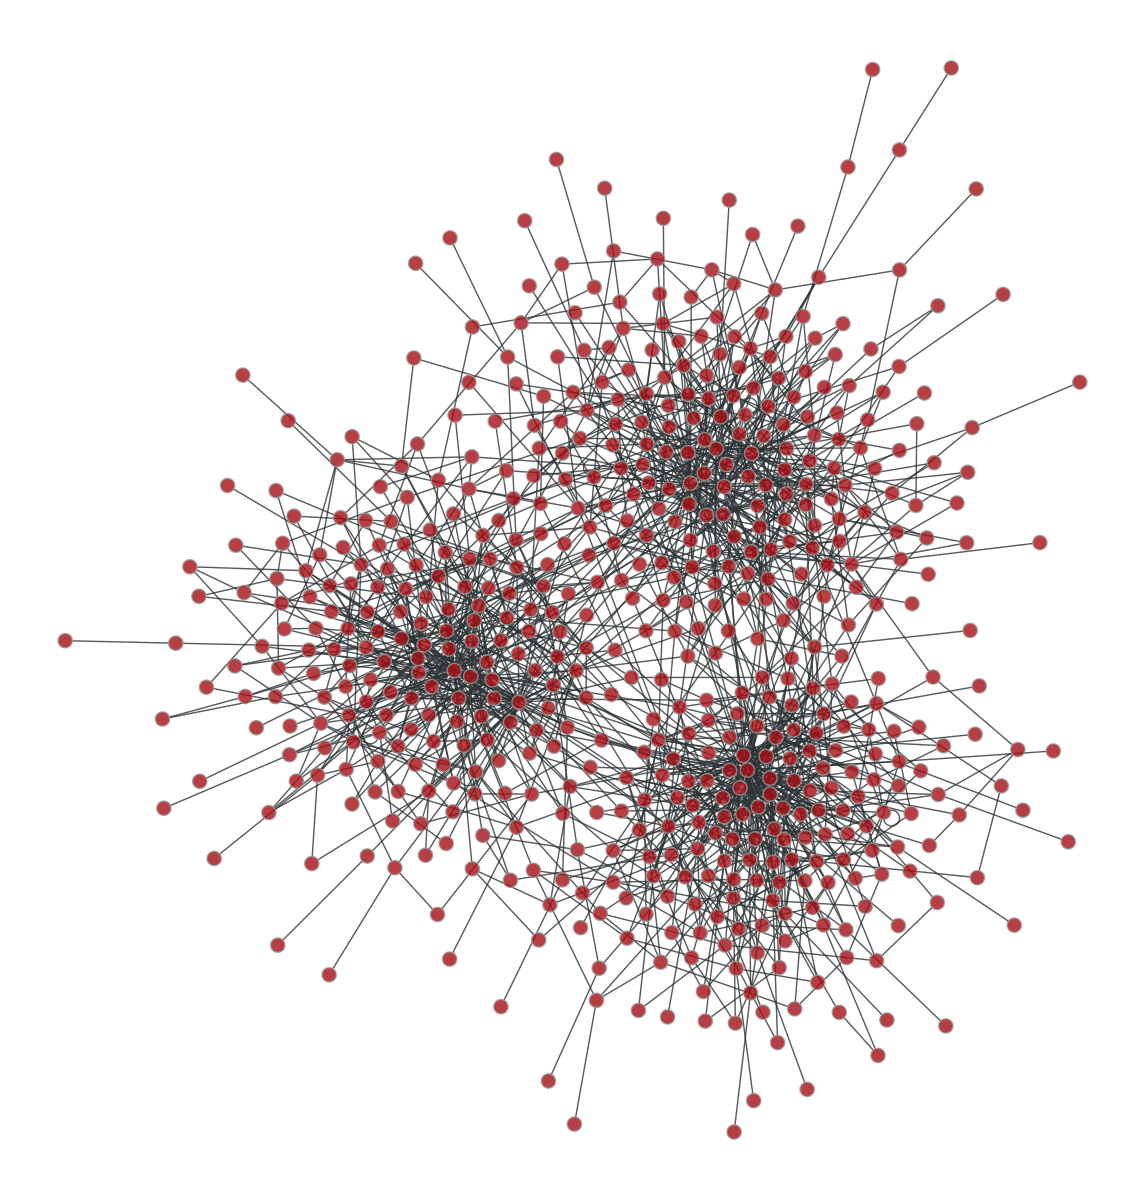

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7a998b22e690, at 0x7a998b26cb90>

In [ ]:
gt.seed_rng(14)


# -------------------------------
# 1. Definir bloques
# -------------------------------
n_blocks = 3
block_size = 200
N = n_blocks * block_size

b = np.repeat(np.arange(n_blocks), block_size)

# -------------------------------
# 2. Matriz de conexiones
# -------------------------------
p_in = 1000   # número esperado de edges intra
p_out = 50   # número esperado inter

probs = np.full((n_blocks, n_blocks), p_out)
np.fill_diagonal(probs, p_in)

# -------------------------------
# 3. Heterogeneidad de grado (θ)
# -------------------------------
theta = np.random.pareto(2., size=N) + 1

# normalización por bloque (importante pero graph-tool lo hace igual)
# (lo dejamos explícito para claridad conceptual)
for r in range(n_blocks):
    idx = (b == r)
    theta[idx] /= theta[idx].sum()

# -------------------------------
# 4. Generar grafo DC-SBM
# -------------------------------
g = gt.generate_sbm(
    b=b,
    probs=probs,
    out_degs=theta
)
g = gt.Graph(gt.GraphView(g, vfilt = gt.label_largest_component(g)), prune=True) # Por simplicidad, nos quedamos con la componente gigante de la red generada
gt.remove_parallel_edges(g) # Y removemos también los posibles autoenlaces
print("Nodos:", g.num_vertices())
print("Aristas:", g.num_edges())

gt.graph_draw(g)

## Non degree corrected
Implementamos el SBM con un block state que no incorpora la posibilidad de que haya una distribución heterogénea de grados. Indagando en la documentación, vemos que es necesario especificar el tipo de "state" a utilizar y pasarle argumentos al mismo.

In [ ]:
gt.seed_rng(20)
state_ndc = gt.minimize_blockmodel_dl(
    g,
    state=gt.BlockState,
    state_args=dict(deg_corr=False)
)

blocks_ndc = state_ndc.get_blocks()
b_ndc = [blocks_ndc[v] for v in g.vertices()]

print("Bloques (sin degree correction):", len(set(b_ndc)))

Bloques (sin degree correction): 6


## Degree corrected
Implementamos el SBM con un block state que sí incorpora la heterogeneidad de grado en el modelo.

In [ ]:
gt.seed_rng(2)

state_dc = gt.minimize_blockmodel_dl(
    g,
    state=gt.BlockState,
    state_args=dict(deg_corr=True)
)

blocks_dc = state_dc.get_blocks()
b_dc = [blocks_dc[v] for v in g.vertices()]

print("Bloques (con degree correction):", len(set(b_dc)))

Bloques (con degree correction): 3


Vizualicemos ahora estos dos resultados en términos de las componentes halladas.

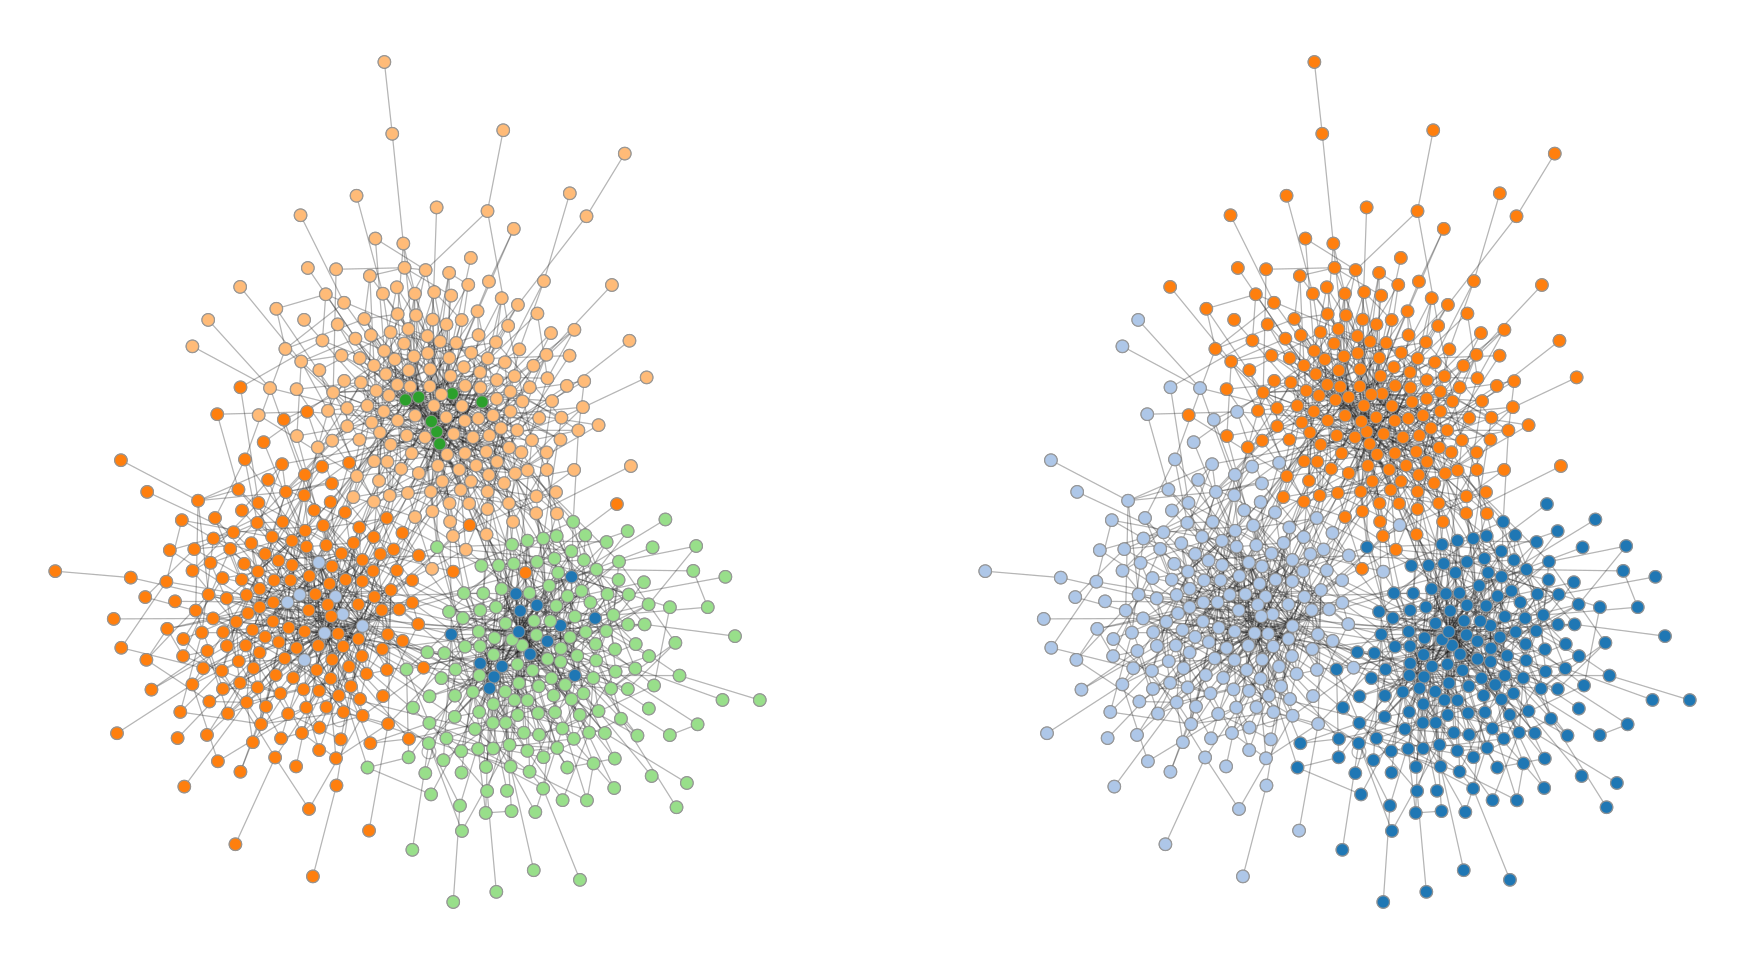

In [ ]:
gt.seed_rng(0)

pos = gt.sfdp_layout(g)

color_ndc = g.new_vertex_property("int")

for v in g.vertices():
    color_ndc[v] = blocks_ndc[v]

color_dc = g.new_vertex_property("int")

for v in g.vertices():
    color_dc[v] = blocks_dc[v]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (11, 6), dpi = 200)

# NDC
gt.graph_draw(
    g,
    pos=pos,
    vertex_fill_color=color_ndc,
    vertex_size=3,
    edge_color = (0.1,0.1,0.1,0.3),
    mplfig = ax1
)

# DC
gt.graph_draw(
    g,
    pos=pos,
    vertex_fill_color=color_dc,
    vertex_size=3,
    edge_color = (0.1,0.1,0.1,0.3),
    mplfig = ax2
)


for ax in fig.get_axes():
    ax.axis('off')

Nuevamente, y teniendo en cuenta que el algoritmo es estocástico, trabajemos en un experimento donde calculemos una y otra descomposición de la red. Calculemos para cada una la cantidad de comunidades encontradas y lo que se llama description length, que está asociado a la cantidad de bits necesarios para poder comprimir la red, dado los parámetros del modelo.

In [ ]:
n_runs = 100

blocks_ndc_list = []
blocks_dc_list = []

entropy_ndc = []
entropy_dc = []

for i in range(n_runs):
    gt.seed_rng(i)  # semilla distinta pero controlada

    # --- NDC ---
    state_ndc = gt.minimize_blockmodel_dl(
        g,
        state=gt.BlockState,
        state_args=dict(deg_corr=False)
    )
    b_ndc = state_ndc.get_blocks()
    blocks_ndc_list.append(len(set(b_ndc)))
    entropy_ndc.append(state_ndc.entropy())

    # --- DC ---
    state_dc = gt.minimize_blockmodel_dl(
        g,
        state=gt.BlockState,
        state_args=dict(deg_corr=True)
    )
    b_dc = state_dc.get_blocks()
    blocks_dc_list.append(len(set(b_dc)))
    entropy_dc.append(state_dc.entropy())

Vizualicemos los resultados.

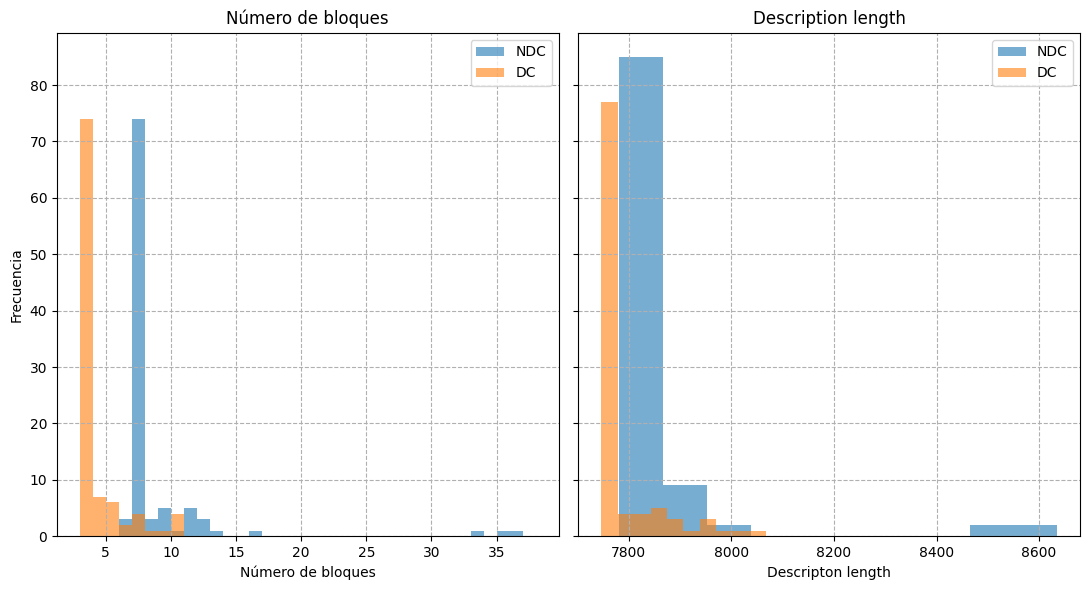

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey = True)

# número de bloques
axes[0].hist(blocks_ndc_list, alpha=0.6, label="NDC", bins = np.arange(min(blocks_ndc_list), max(blocks_ndc_list), 1))
axes[0].hist(blocks_dc_list, alpha=0.6, label="DC", bins = np.arange(min(blocks_dc_list), max(blocks_dc_list), 1))
axes[0].set_title("Número de bloques")
axes[0].set_xlabel('Número de bloques')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# description length (entropy)
axes[1].hist(entropy_ndc, alpha=0.6, label="NDC")
axes[1].hist(entropy_dc, alpha=0.6, label="DC")
axes[1].set_title("Description length")
axes[1].set_xlabel('Descripton length')
axes[1].legend()
for ax in fig.get_axes():
    ax.grid(linestyle = 'dashed')

plt.tight_layout()
plt.show()